# Wave Glider OSSE: Hexagon Array Comparison

Compares w estimation across 4 hexagon diameters centered at 0°N 140°W.
Model loaded once; each configuration reuses the same dataset.

In [1]:
import numpy as np
import os
import sys
sys.path.insert(0, '/home/edavenport/analysis/tpose24-osse')
from osse_tools import load_model, sample_uv, compute_w_planefit, sample_model_w, plot_w_comparison, plot_velocity_map
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Configuration

In [2]:
RUN_DIR   = "/data/SO3/edavenport/tpose24/oct2012_3month_transp_cons"
ITERS     = list(range(36, 26173, 36))  # 3-hourly, Oct-Dec 2012

DIAMETERS = [0.25, 0.5, 0.75, 1.0]     # hexagon diameters in degrees

lat_c, lon_c = 0.0, 220.0              # array center: 0°N 140°W

## Load model (once)

In [3]:
ds = load_model(RUN_DIR, ITERS)
ds = ds.sel(time=slice("2012-10-11", None))  # exclude spin-up (Oct 1-10)

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

...

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons or /data/SO3/edavenport/tpose24/oct2012_3month_transp_cons. Using default version.
  warnings.warn

## Run all configurations

In [4]:
results = {}

for diam in DIAMETERS:
    radius    = diam / 2
    angles    = np.linspace(0, 2 * np.pi, 7)[:-1]
    positions = [(lat_c + radius * np.sin(a), lon_c + radius * np.cos(a))
                 for a in angles]

    uv      = sample_uv(ds, positions, max_depth=70, dz_obs=2)
    w_est   = compute_w_planefit(uv)["w_est"]
    w_model = sample_model_w(ds, positions, max_depth=70, dz_obs=2)
    bias    = w_est - w_model

    results[diam] = dict(
        positions=positions,
        w_est=w_est,
        w_model=w_model,
        bias=bias,
        rms=float(np.sqrt((bias**2).mean())),
        mean_bias=float(bias.mean()),
    )
    print(f"diam={diam}°  RMS={results[diam]['rms']:.3e} m/s  "
          f"bias={results[diam]['mean_bias']:+.3e} m/s")

diam=0.25°  RMS=2.621e-05 m/s  bias=-2.930e-06 m/s


diam=0.5°  RMS=4.577e-05 m/s  bias=-3.679e-06 m/s


diam=0.75°  RMS=5.615e-05 m/s  bias=-1.081e-06 m/s


diam=1.0°  RMS=6.376e-05 m/s  bias=+3.164e-07 m/s


## Comparison figures

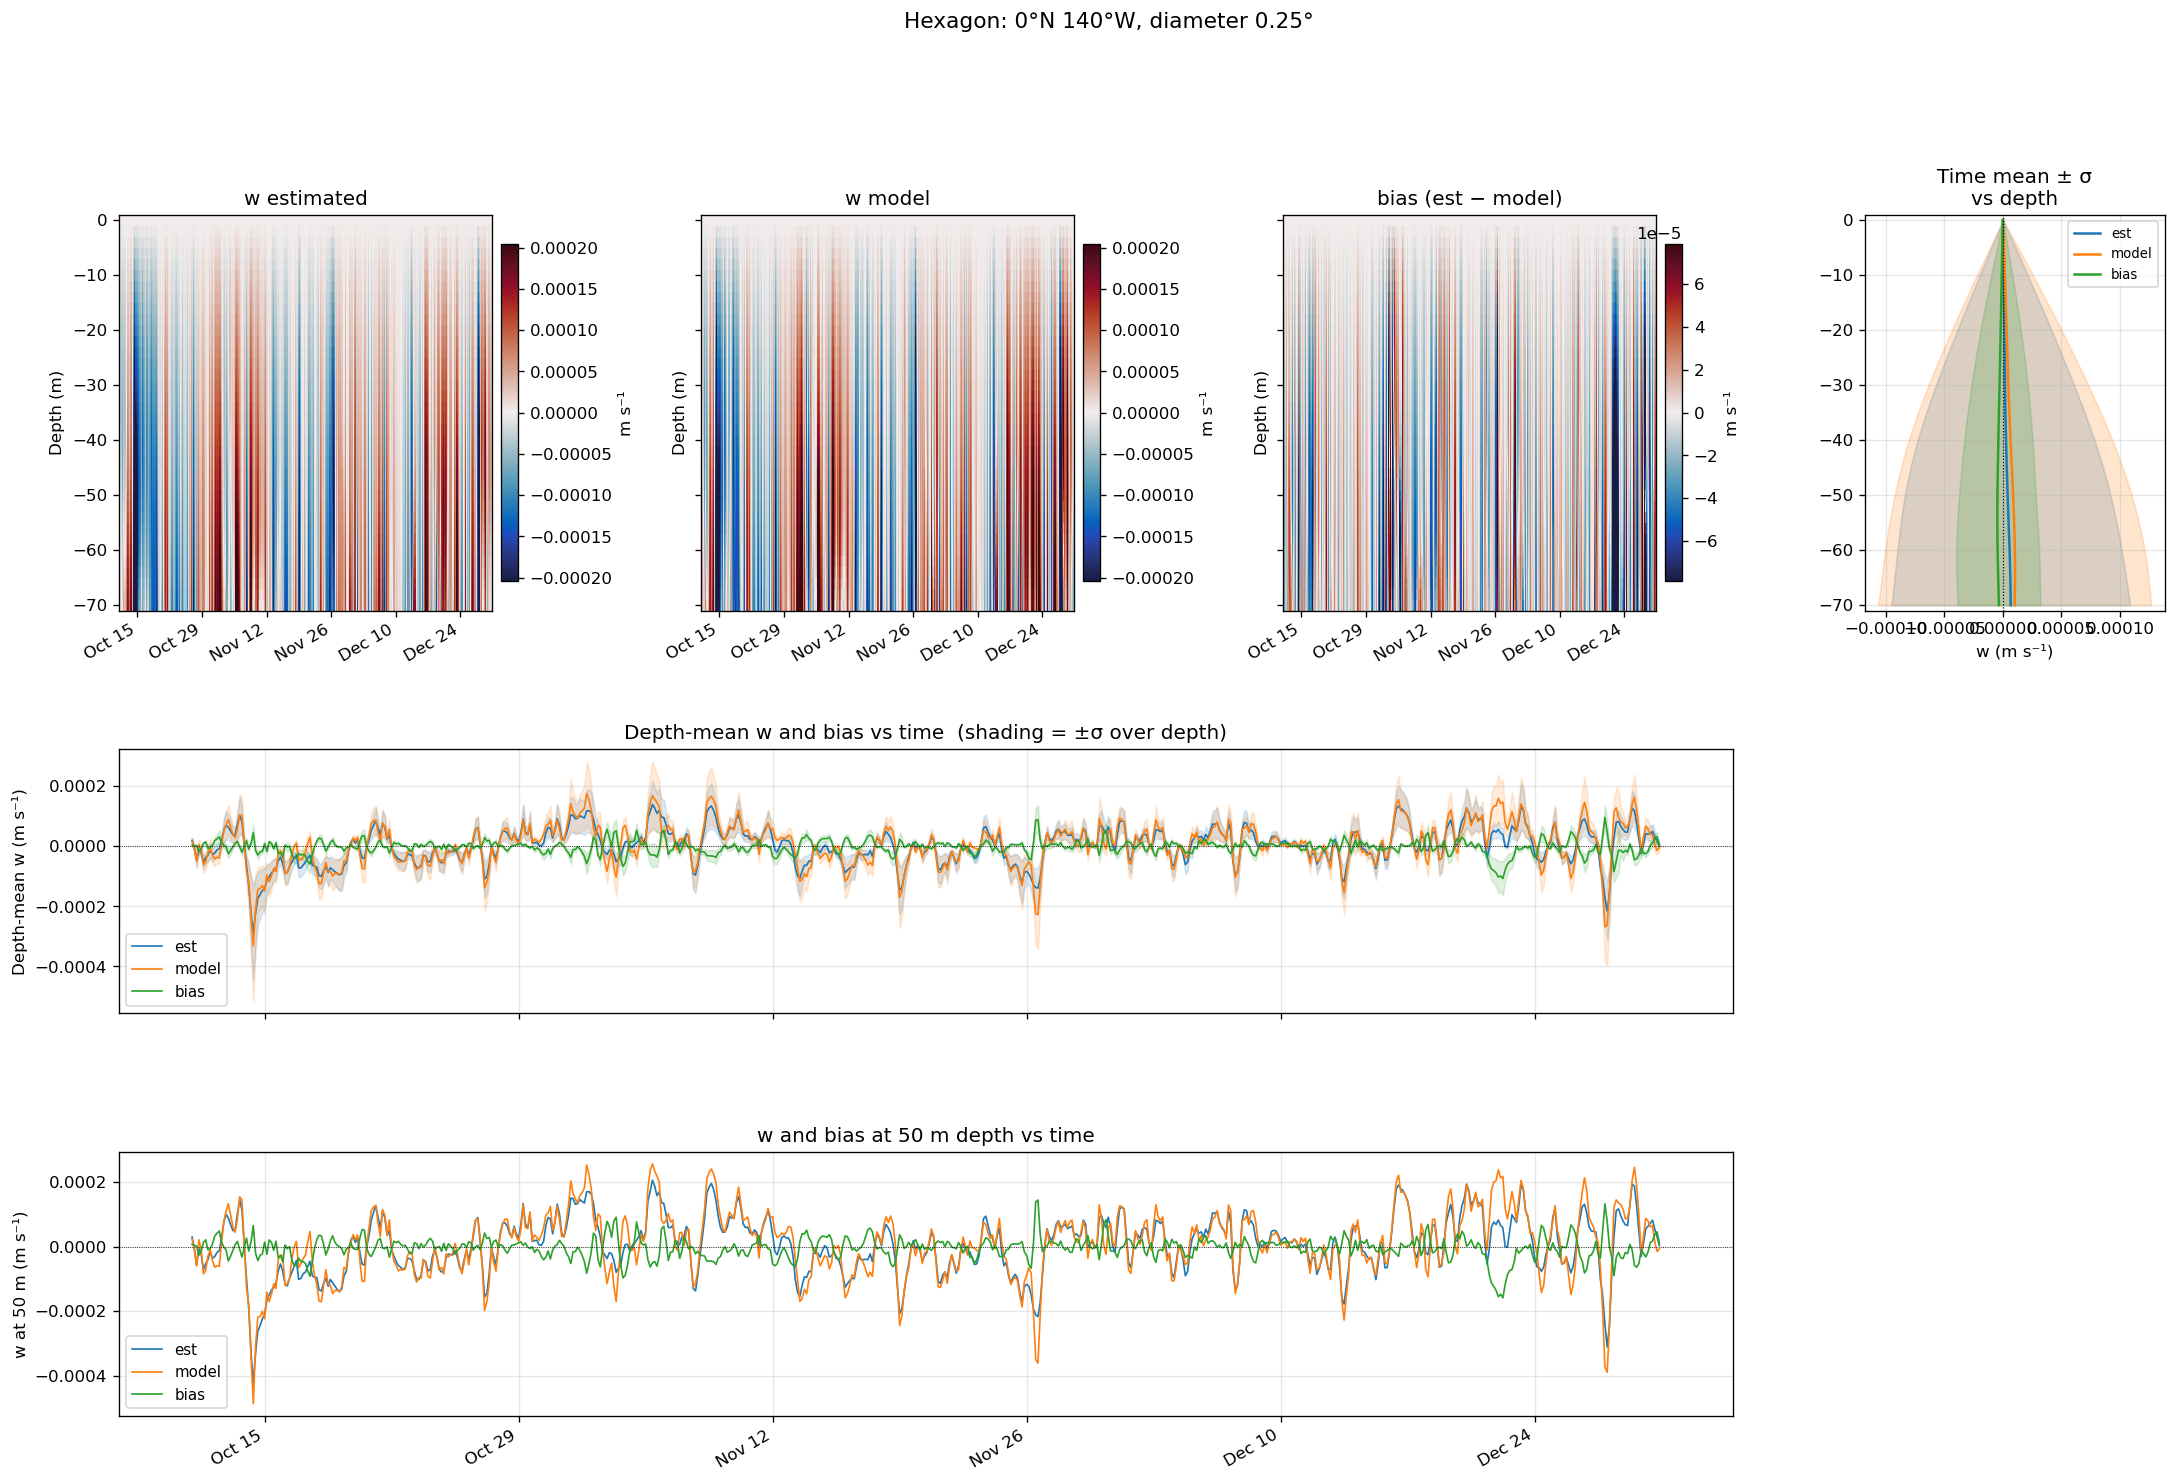

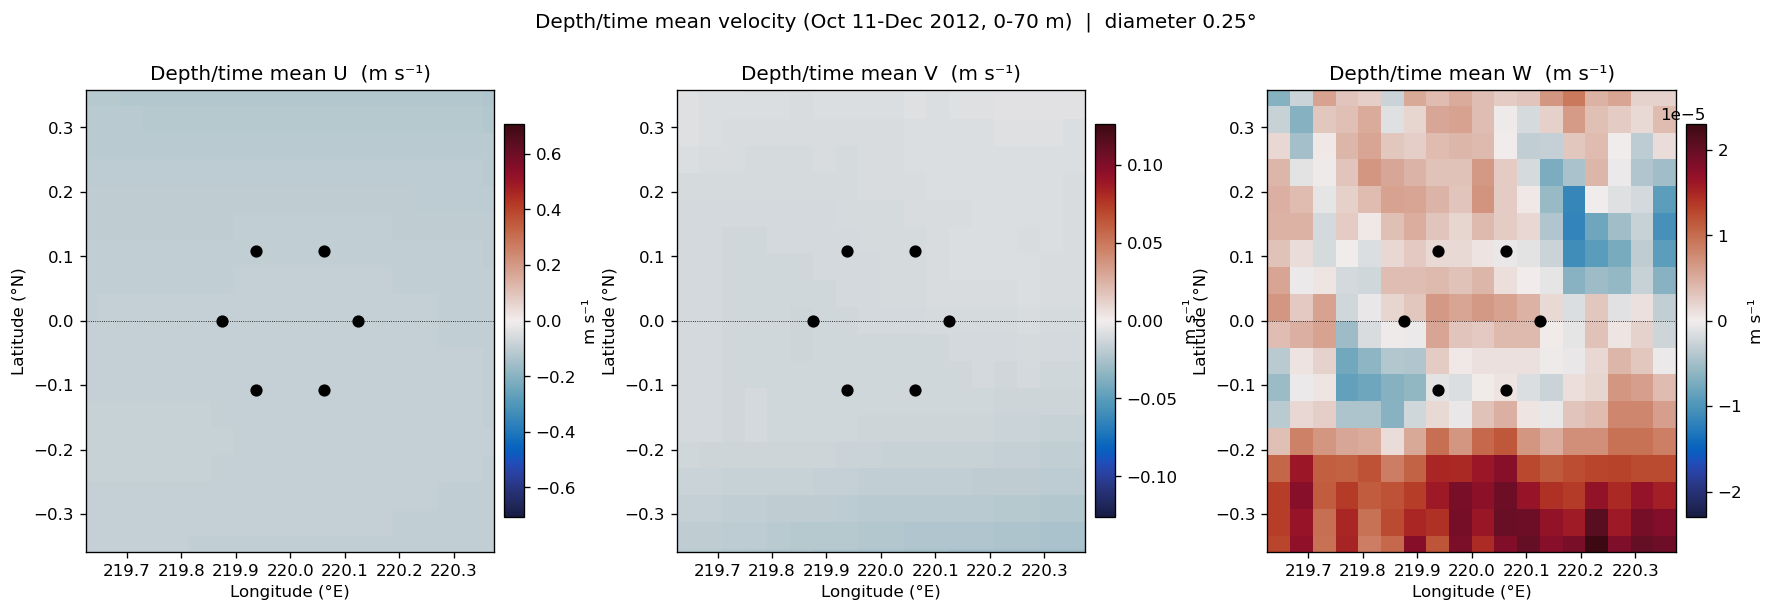

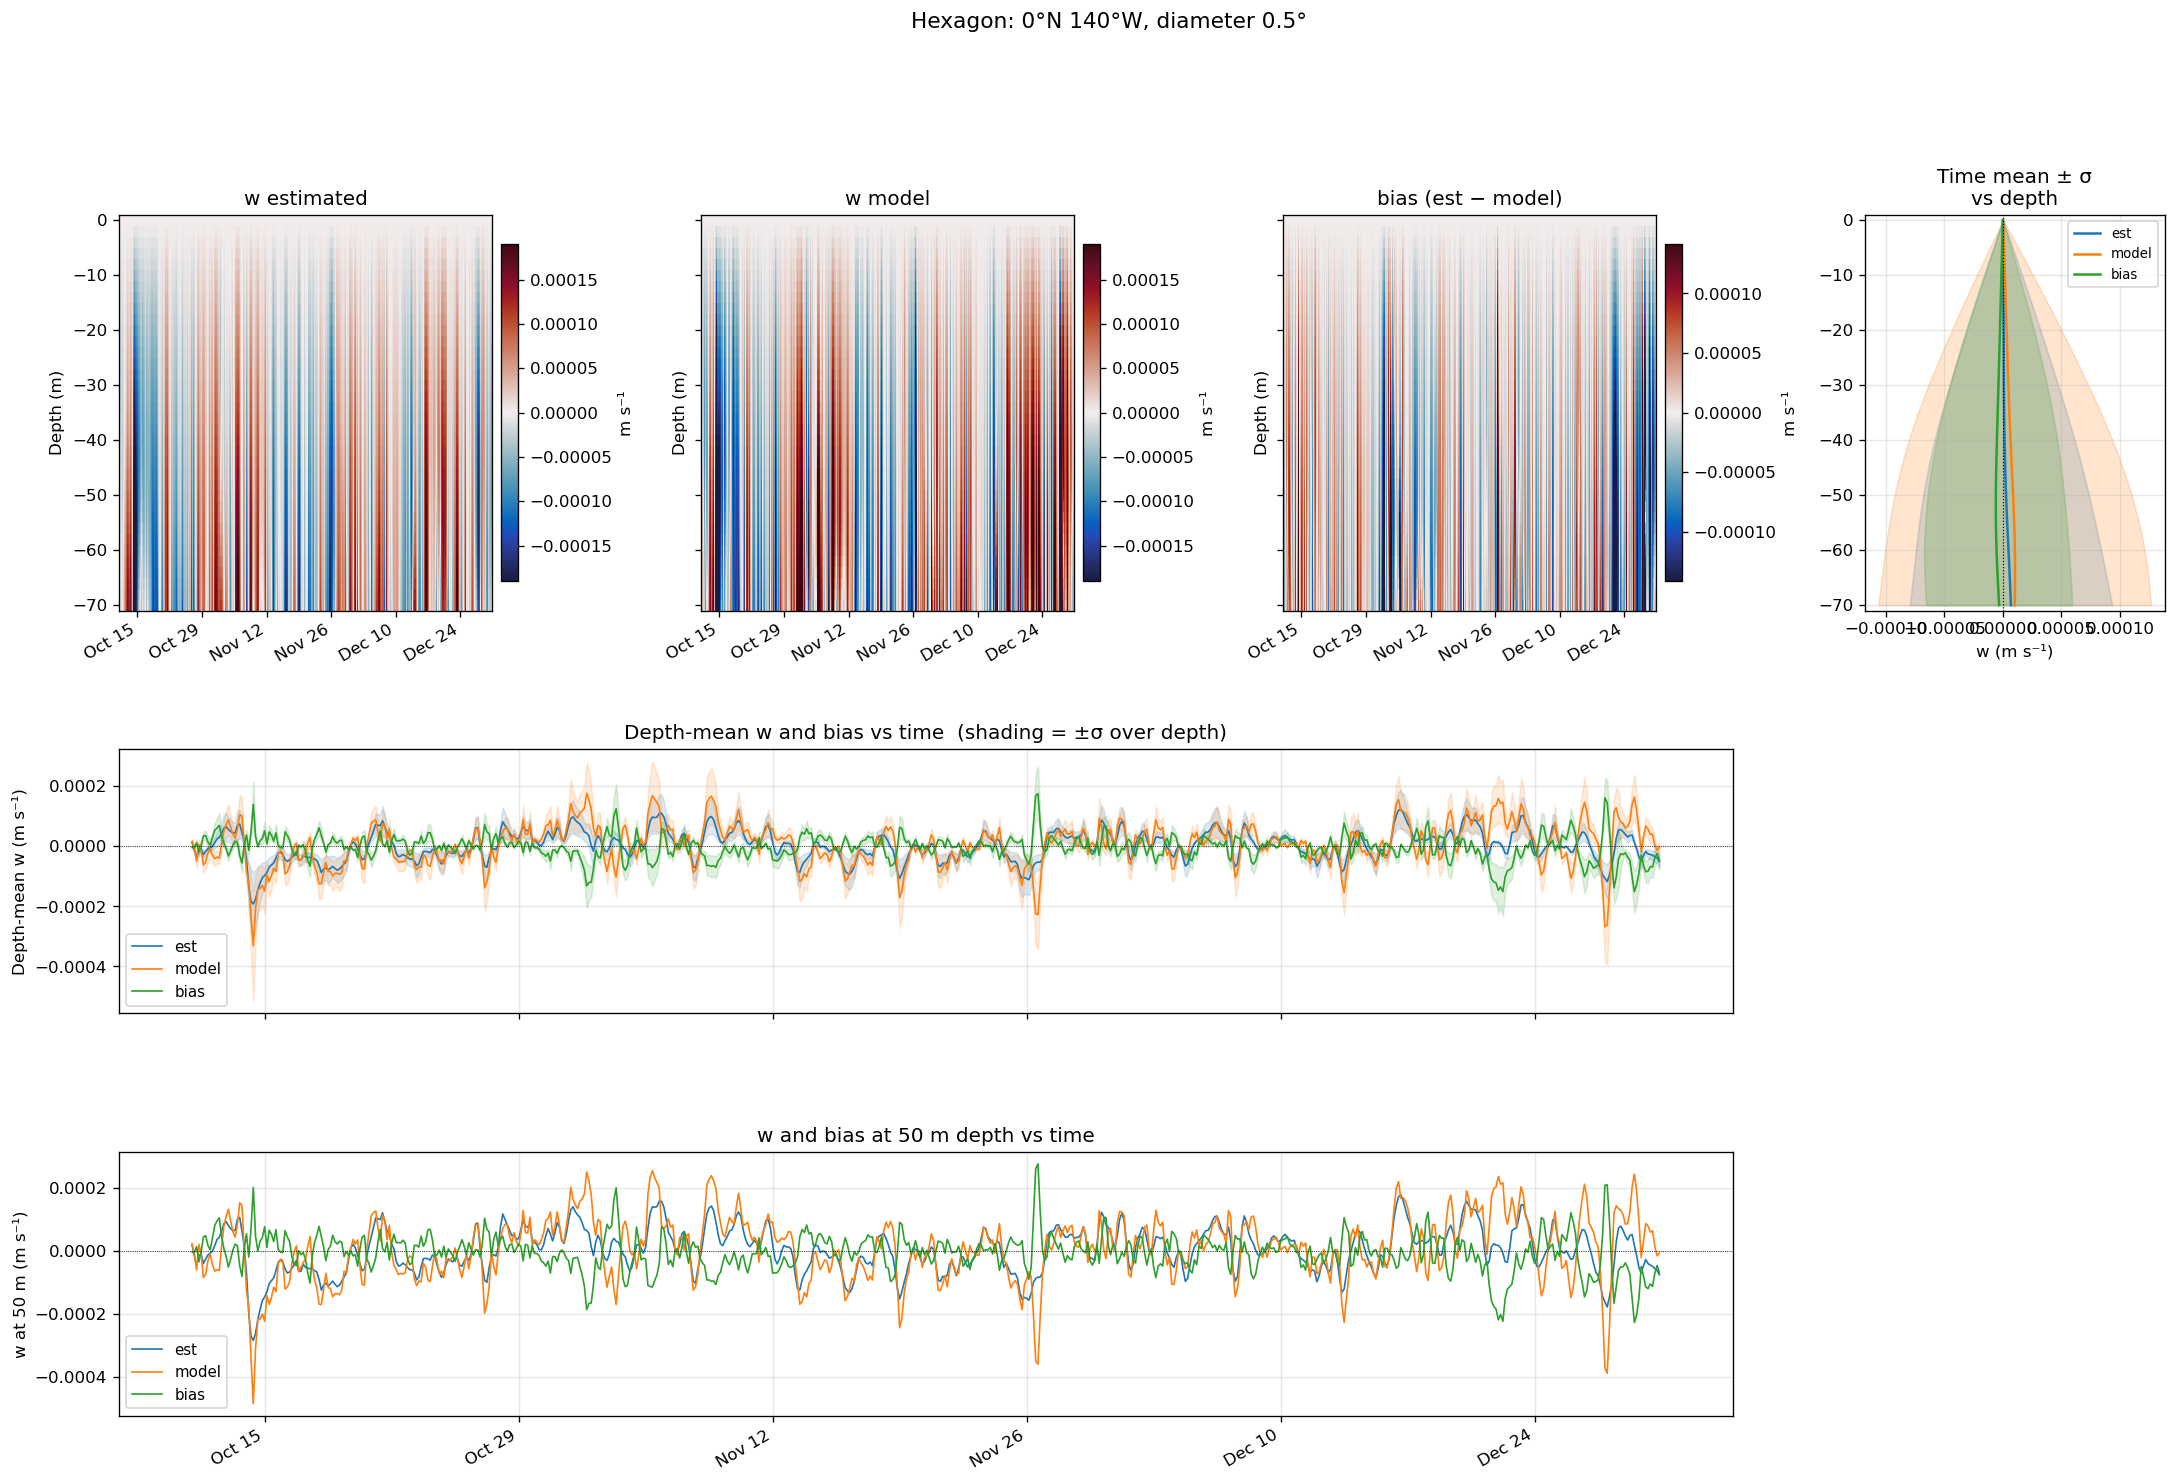

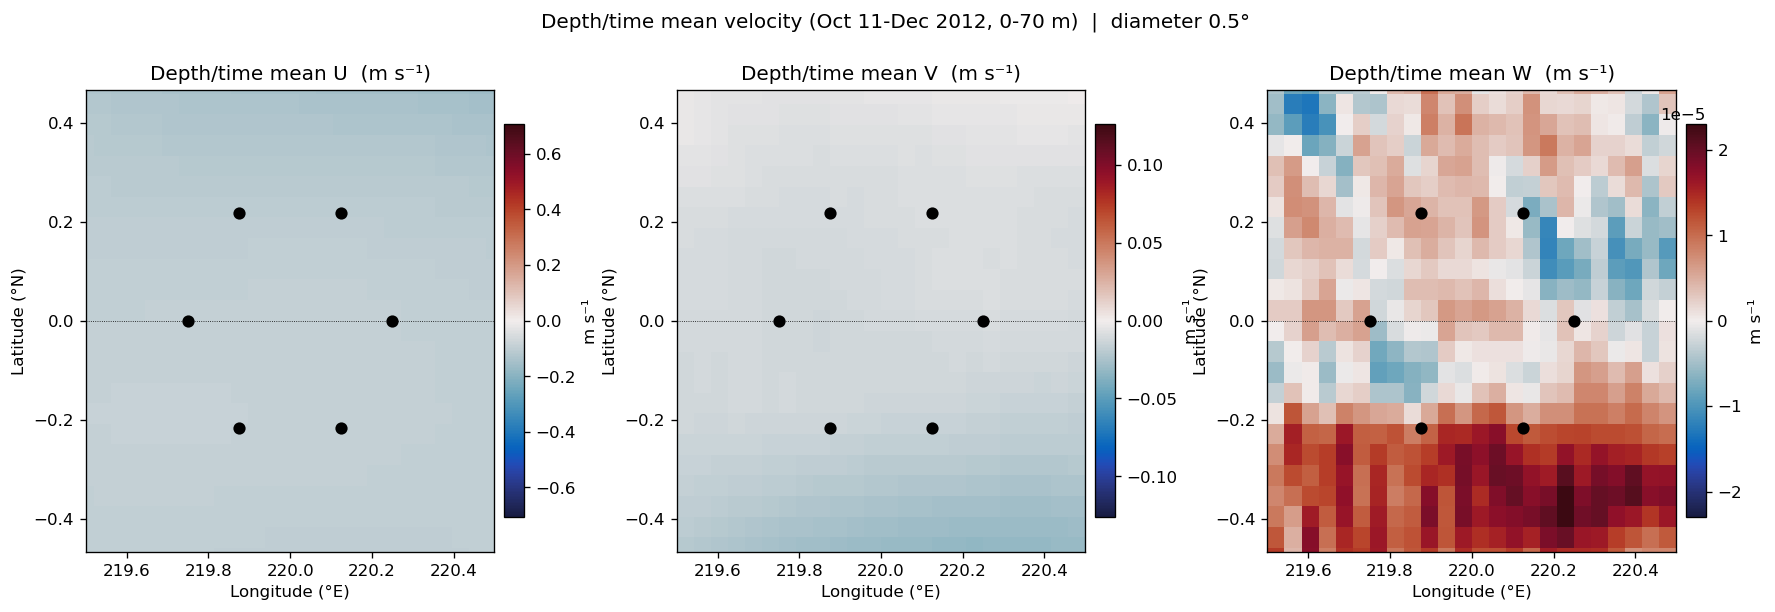

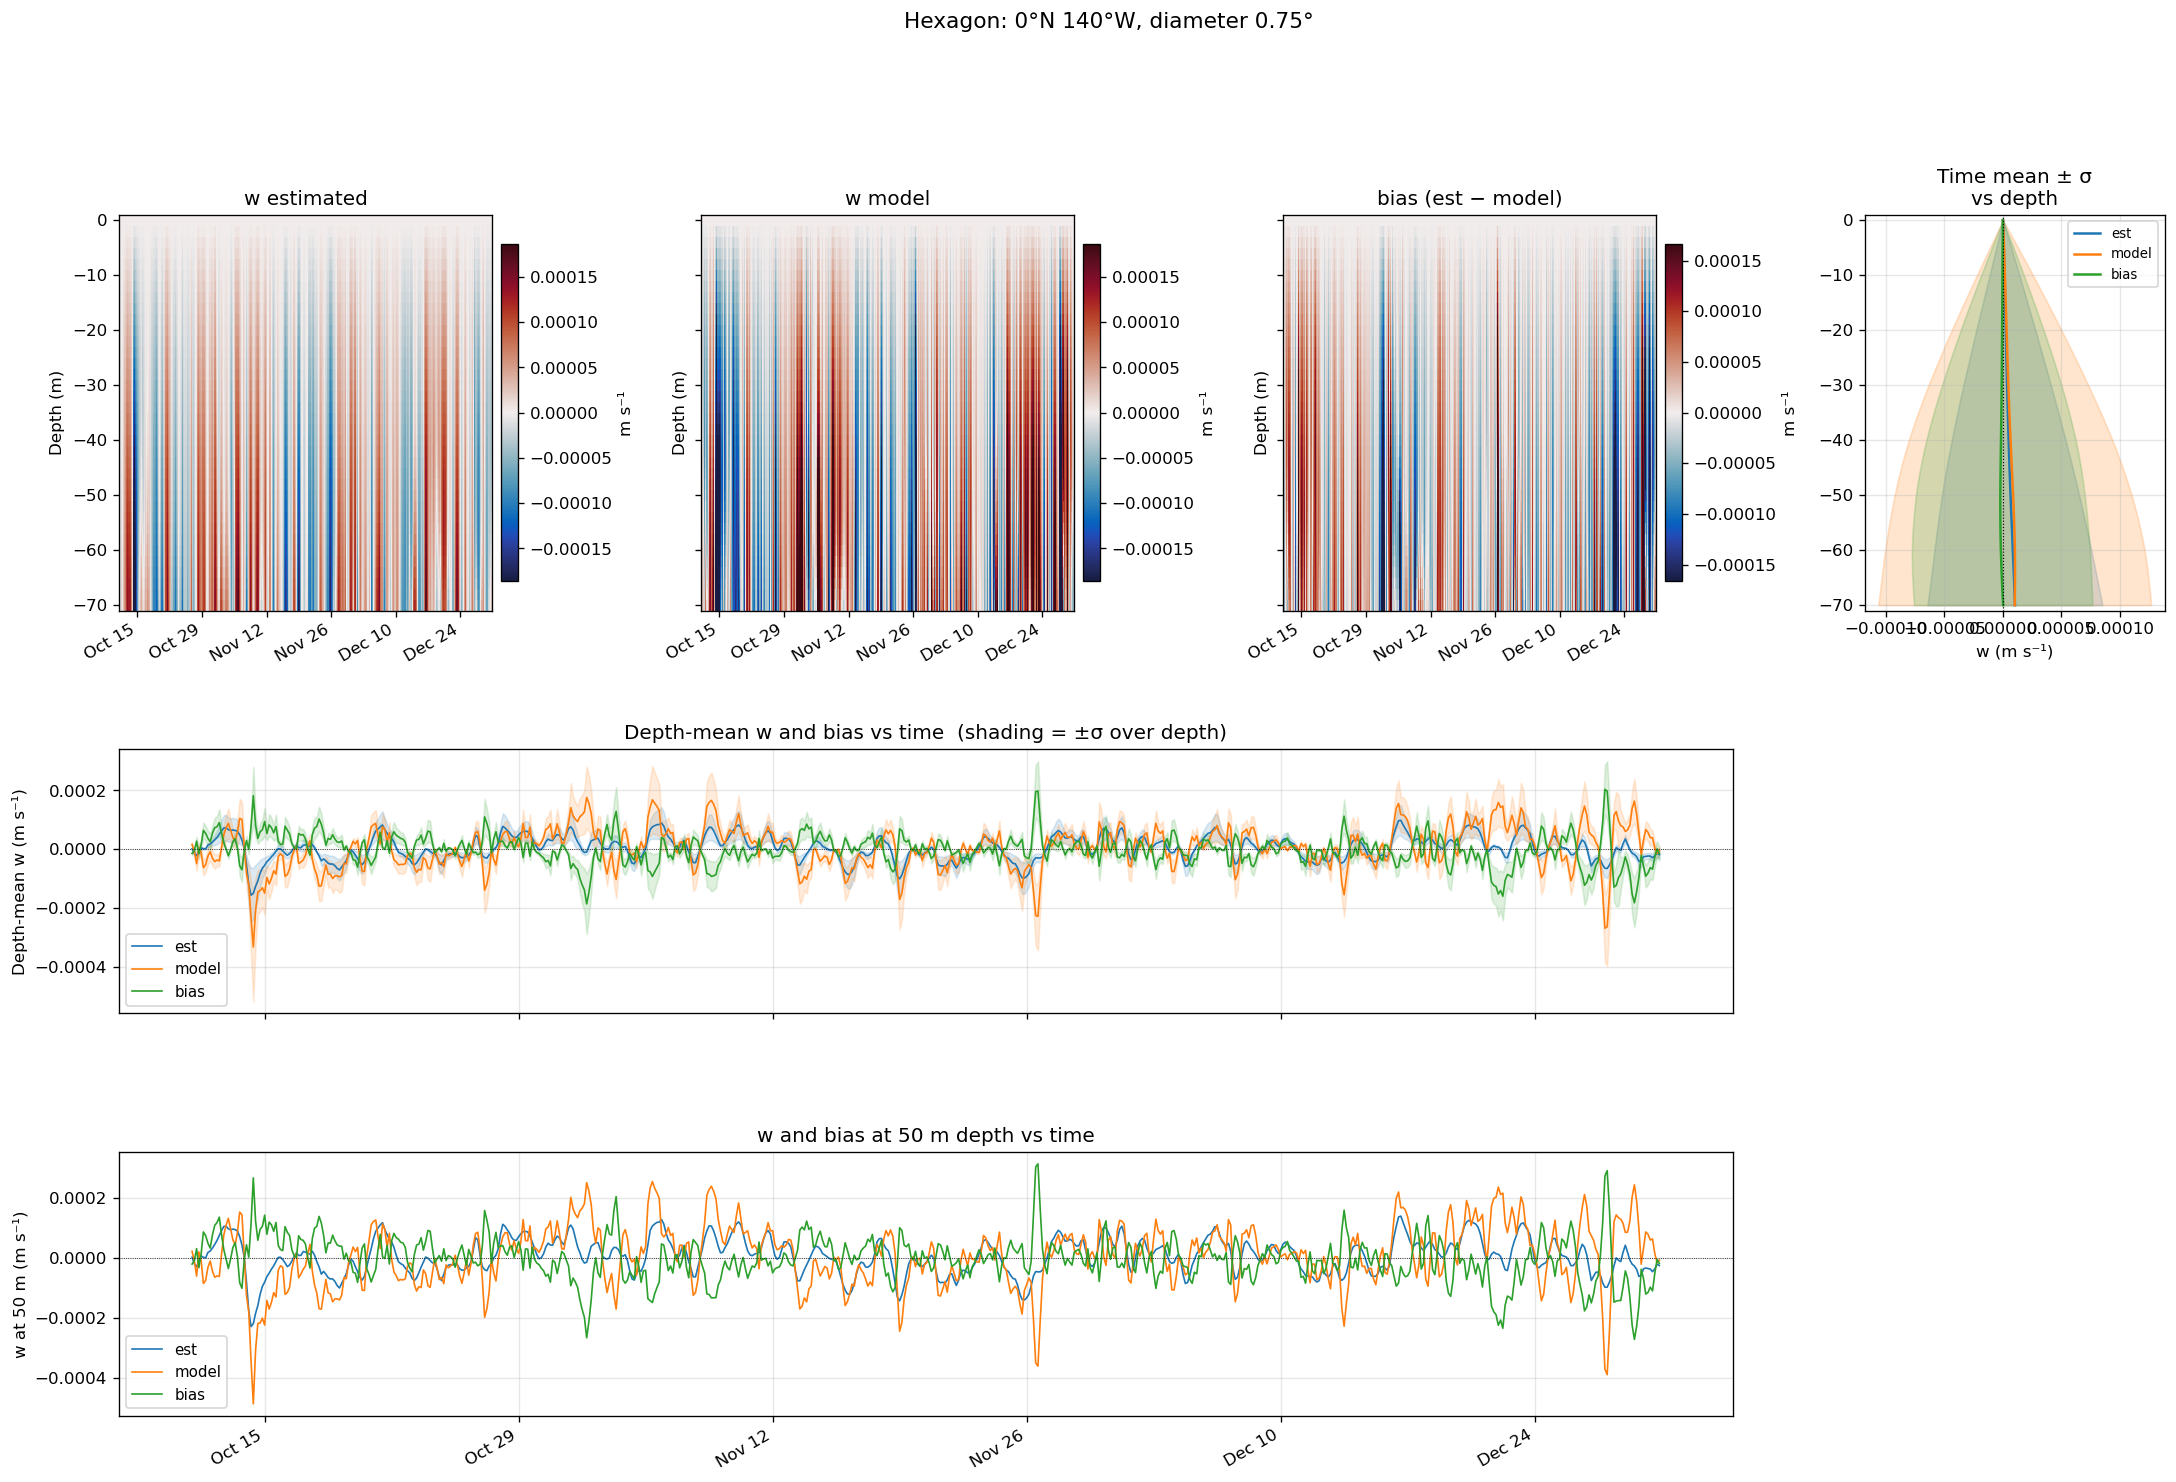

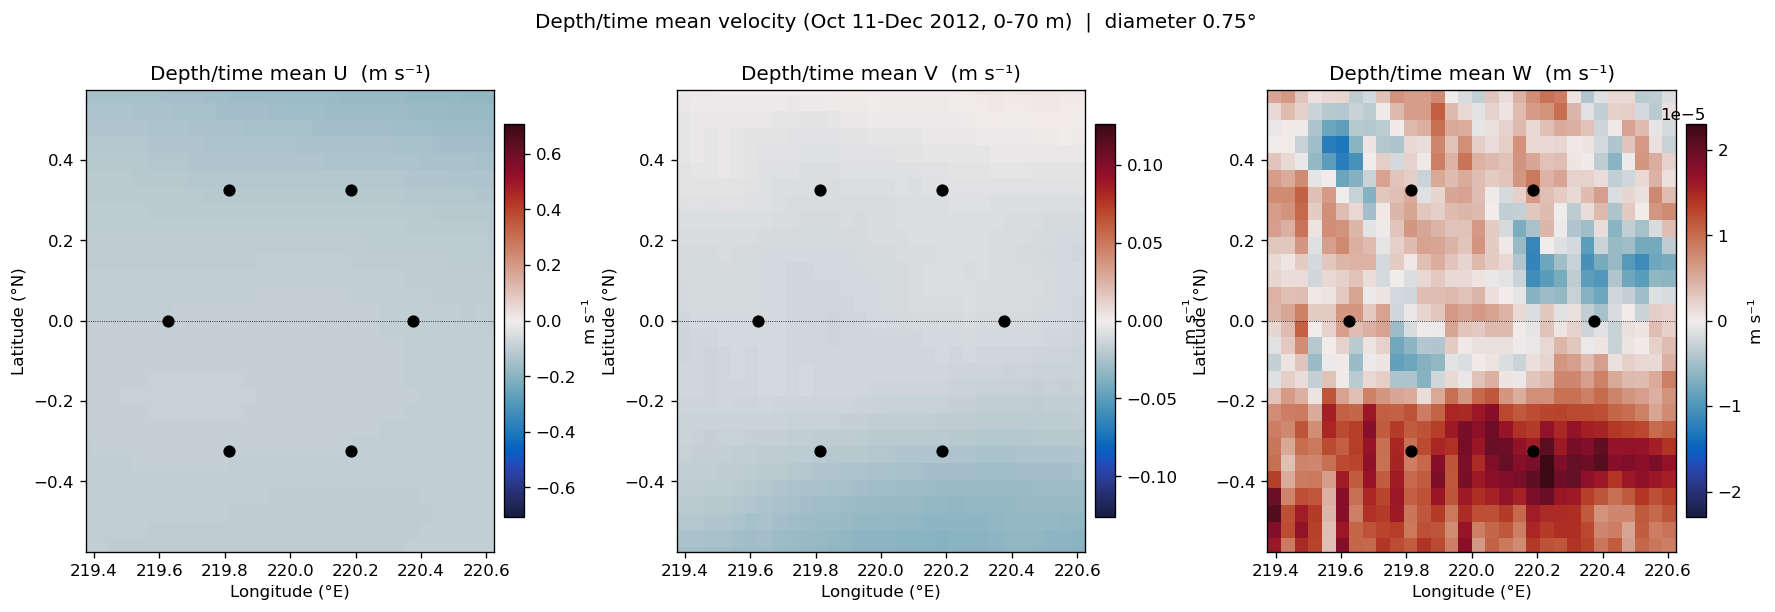

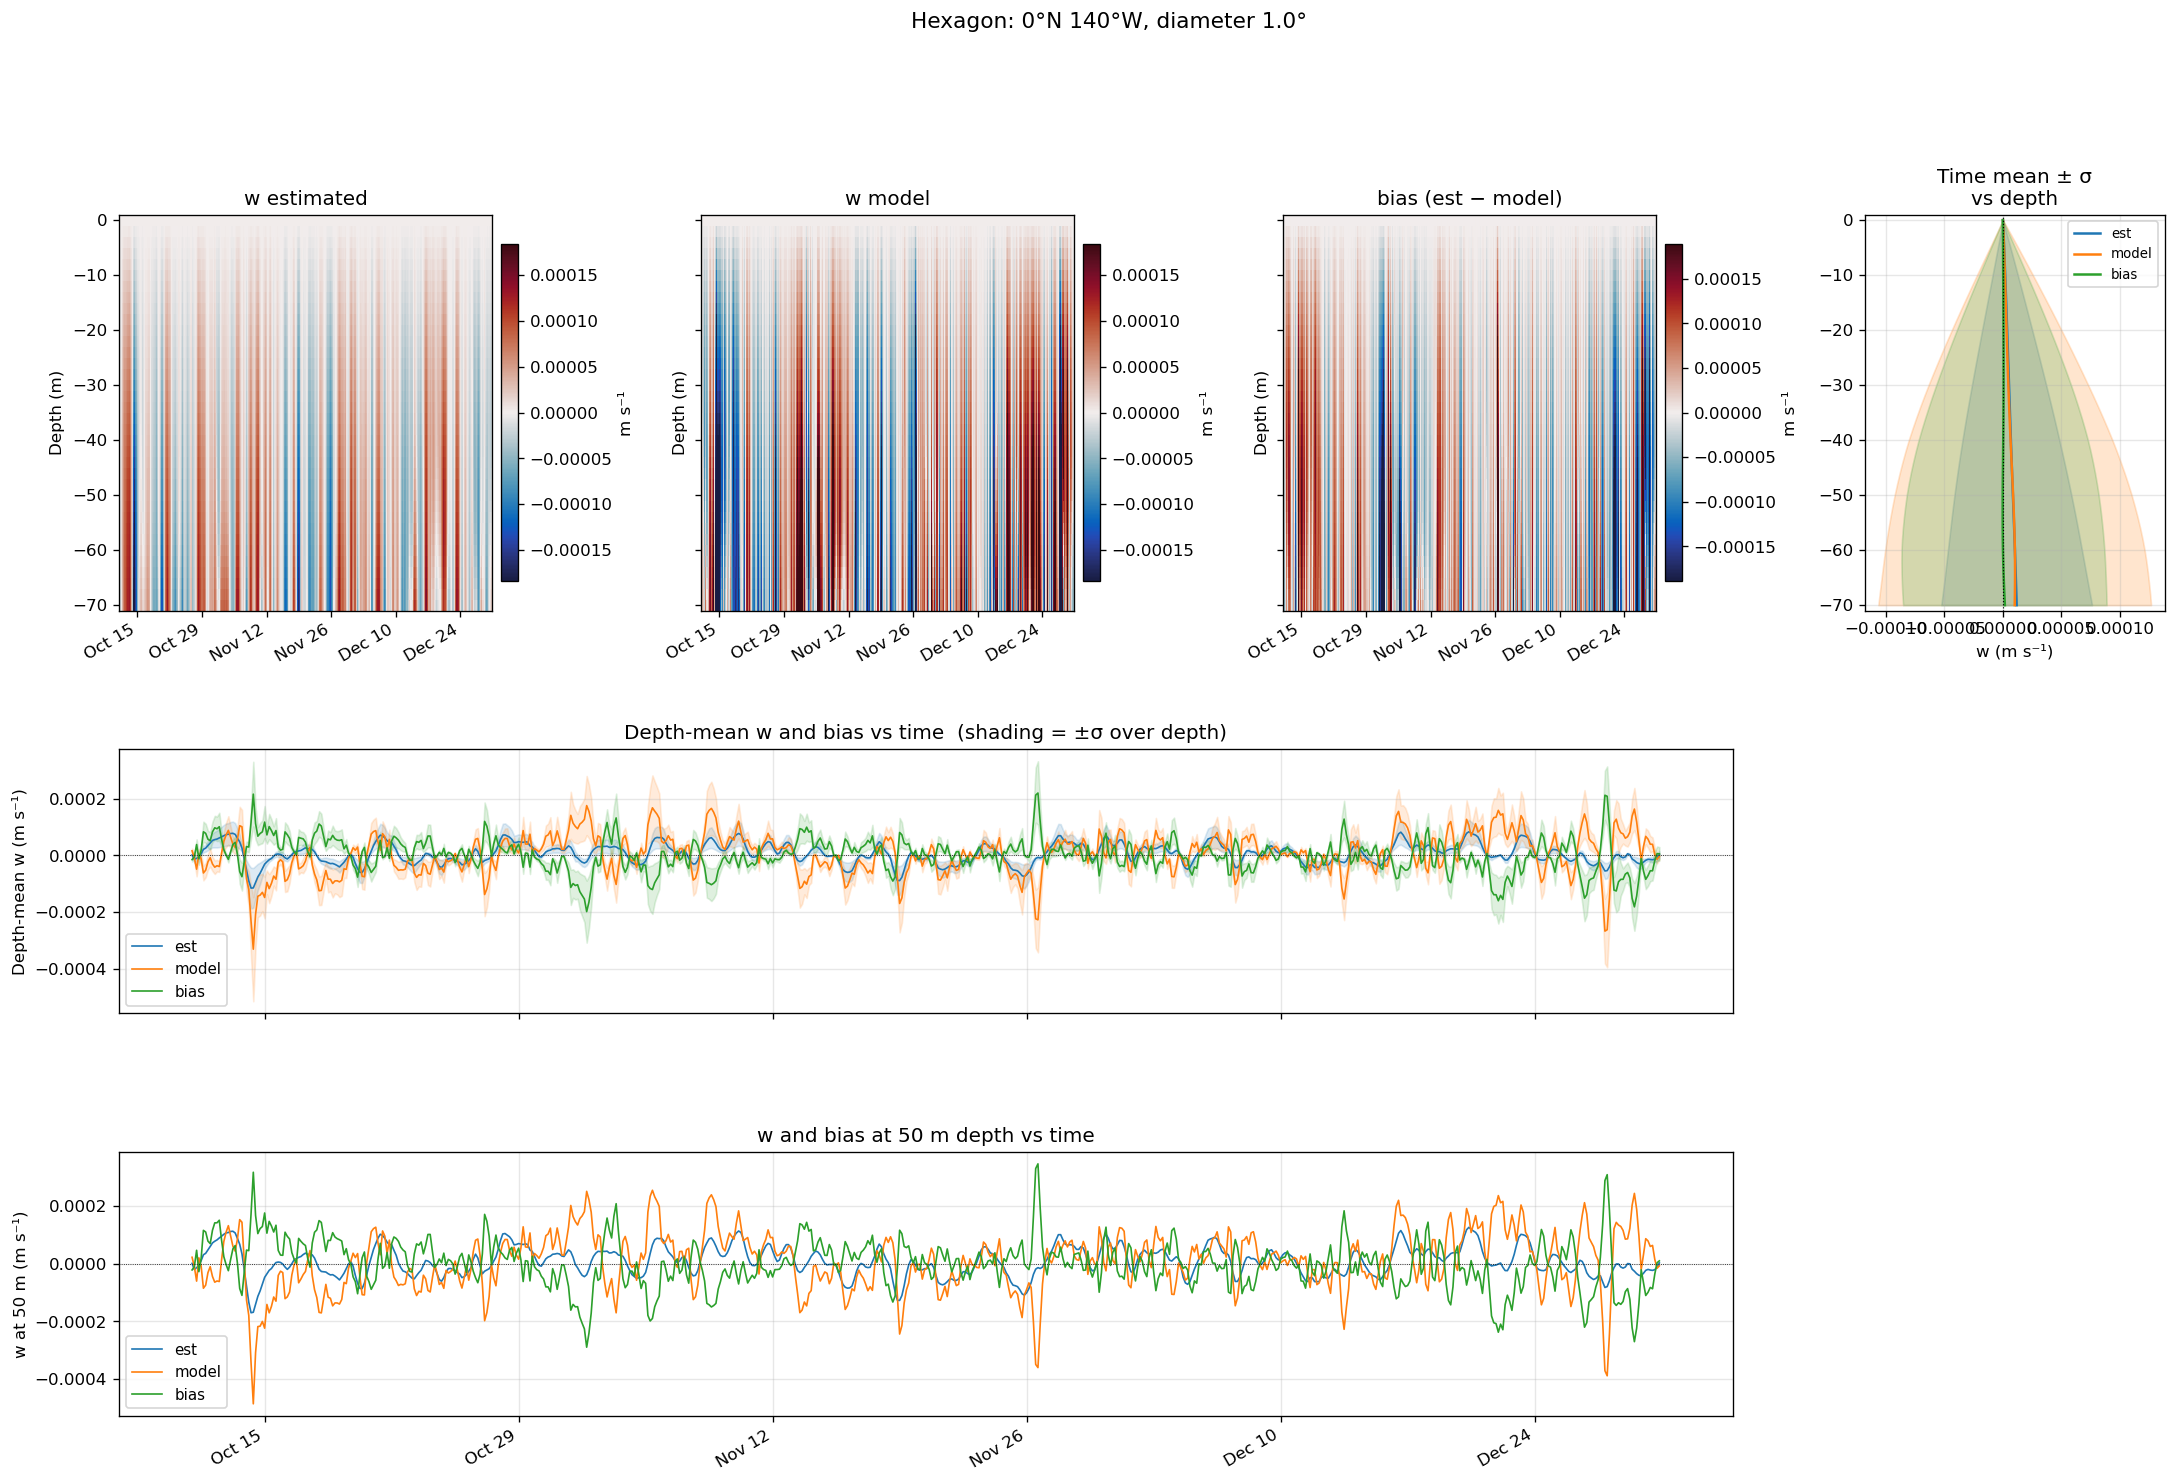

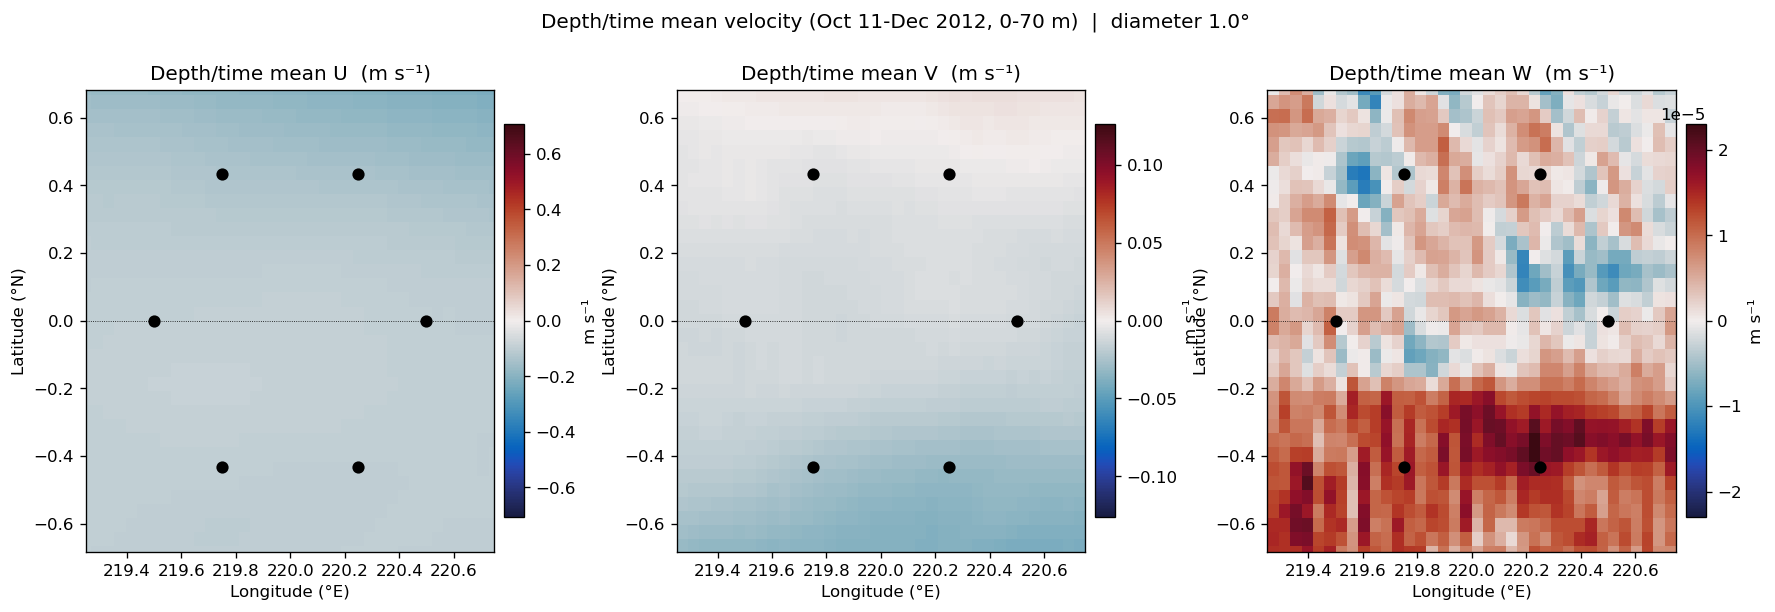

In [5]:
for diam, r in results.items():
    outdir = f"hex-{diam}"
    os.makedirs(outdir, exist_ok=True)

    fig = plot_w_comparison(r["w_est"], r["w_model"], point_depth=-50)
    fig.suptitle(f"Hexagon: 0°N 140°W, diameter {diam}°", fontsize=13, y=1.01)
    plt.savefig(f"{outdir}/w_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig2 = plot_velocity_map(ds, r["positions"], max_depth=70)
    fig2.suptitle(
        f"Depth/time mean velocity (Oct 11-Dec 2012, 0-70 m)  |  diameter {diam}°",
        fontsize=12, y=1.01)
    plt.savefig(f"{outdir}/velocity_map.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary across configurations

In [6]:
header = f"{"Diameter":>10}  {"RMS (m/s)":>12}  {"Mean bias (m/s)":>16}  {"w_est std":>12}  {"w_model std":>12}"
print(header)
print("-" * len(header))
for diam, r in results.items():
    print(f"{str(diam) + chr(176):>10}  "
          f"{r['rms']:>12.3e}  "
          f"{r['mean_bias']:>+16.3e}  "
          f"{float(r['w_est'].std()):>12.3e}  "
          f"{float(r['w_model'].std()):>12.3e}")

  Diameter     RMS (m/s)   Mean bias (m/s)     w_est std   w_model std
----------------------------------------------------------------------
     0.25°     2.621e-05        -2.930e-06     6.894e-05     7.956e-05
      0.5°     4.577e-05        -3.679e-06     5.604e-05     7.956e-05
     0.75°     5.615e-05        -1.081e-06     4.682e-05     7.956e-05
      1.0°     6.376e-05        +3.164e-07     4.005e-05     7.956e-05


In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(DIAMETERS)))

for (diam, r), color in zip(results.items(), colors):
    T        = r["bias"].time.values
    bias_dm  = r["bias"].mean("depth")
    bias_50  = r["bias"].sel(depth=-50, method="nearest")
    axes[0].plot(T, bias_dm.values, color=color, lw=1.2, label=f"{diam}°")
    axes[1].plot(T, bias_50.values, color=color, lw=1.2, label=f"{diam}°")

for ax, title, ylabel in zip(
    axes,
    ["Depth-mean w error vs time", "w error at 50 m vs time"],
    ["depth-mean (est − model)  (m s⁻¹)",
     "est − model at 50 m  (m s⁻¹)"],
):
    ax.axhline(0, color="k", lw=0.5, ls=":")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="Diameter", fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.suptitle("Hexagon array: w error comparison across configurations",
             fontsize=13)
fig.tight_layout()
plt.savefig("hexagon_error_comparison.png", dpi=150, bbox_inches="tight")
plt.show()